Imports

In [1]:
!pip install tensorflow numpy pandas scikit-learn matplotlib

In [2]:
# ------------------- Imports -------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, GRU, Conv1D, MaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber


Load and Preprocess Dataset

In [3]:
# ------------------- Data Loading & Scaling -------------------
file_path = "/content/Combined_AQ_Weather_NO2_AQI_2024_Robust.csv"
df = pd.read_csv(file_path)

# Drop unnecessary columns
df = df.drop(columns=["Datetime", "City", "AQI_Category"])

# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Scale all numeric features
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

print("Scaled Data Shape:", scaled_df.shape)
scaled_df.head()


Scaled Data Shape: (26445, 14)


,PM2.5,PM10,NO,CO,Ozone,temperature_2m,relative_humidity_2m,precipitation,rain,pressure_msl,windspeed_10m,winddirection_10m,NO2,Final_AQI
0,0.124192,0.191329,0.027280,0.044532,0.043229,0.086758,1.000000,0.0,0.0,0.827586,0.102902,0.844011,0.021750,0.582517
1,0.106026,0.168907,0.029428,0.044118,0.036185,0.164384,0.905263,0.0,0.0,0.859195,0.087071,0.983287,0.023032,0.465293
2,0.125578,0.198320,0.030822,0.044532,0.041597,0.173516,0.894737,0.0,0.0,0.870690,0.094987,1.000000,0.024101,0.591518
3,0.106238,0.182708,0.036739,0.044532,0.034489,0.191781,0.863158,0.0,0.0,0.887931,0.142480,0.008357,0.029228,0.466693
4,0.107676,0.199430,0.050242,0.044739,0.036915,0.205479,0.821053,0.0,0.0,0.905172,0.160950,0.005571,0.038287,0.475895


Sequence Creation Functions

In [4]:
# ------------------- Sequence Builders -------------------
def create_sequences(data, target_col, time_steps=24):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    for i in range(time_steps, len(data)):
        X.append(data.iloc[i-time_steps:i].values)
        y.append(data.iloc[i, target_idx])
    return np.array(X), np.array(y)

# 24-hour sequences for CNN-LSTM and BiLSTM
X_24, y_24 = create_sequences(scaled_df, "Final_AQI", time_steps=24)

# 36-hour sequences for GRU (longer memory)
X_36, y_36 = create_sequences(scaled_df, "Final_AQI", time_steps=36)

# Chronological 80/20 splits
split_24 = int(len(X_24) * 0.8)
split_36 = int(len(X_36) * 0.8)

X_train, X_test = X_24[:split_24], X_24[split_24:]
y_train, y_test = y_24[:split_24], y_24[split_24:]

Xg_train, Xg_test = X_36[:split_36], X_36[split_36:]
yg_train, yg_test = y_36[:split_36], y_36[split_36:]

print(f"24-hour Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")
print(f"36-hour GRU Train Shape: {Xg_train.shape}, Test Shape: {Xg_test.shape}")


24-hour Train Shape: (21136, 24, 14), Test Shape: (5285, 24, 14)
36-hour GRU Train Shape: (21127, 36, 14), Test Shape: (5282, 36, 14)


Model Builders

In [5]:
# ------------------- Model Builders -------------------
def build_cnn_lstm(input_shape):
    model = Sequential([
        Conv1D(64, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse')
    return model

def build_bilstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=False), input_shape=input_shape),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss=Huber(delta=0.1))
    return model

def build_gru(input_shape):
    model = Sequential([
        GRU(64, return_sequences=False, input_shape=input_shape),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse')
    return model


Training Function

In [6]:
# ------------------- Training Helper -------------------
def train_and_evaluate(model_fn, X_train, y_train, X_test, y_test, name, epochs=40, batch_size=32):
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = model_fn(input_shape)
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                        epochs=epochs, batch_size=batch_size, verbose=1)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name} -> RMSE: {rmse:.3f}, R²: {r2:.3f}")
    return model, preds, history


Train All Three Models

In [7]:
# ------------------- Model Training -------------------
cnn_lstm_model, pred_cnnlstm, hist_cnnlstm = train_and_evaluate(
    build_cnn_lstm, X_train, y_train, X_test, y_test, "CNN-LSTM (MSE)", epochs=40
)

bilstm_model, pred_bilstm, hist_bilstm = train_and_evaluate(
    build_bilstm, X_train, y_train, X_test, y_test, "BiLSTM (Huber)", epochs=40
)

gru_model, pred_gru, hist_gru = train_and_evaluate(
    build_gru, Xg_train, yg_train, Xg_test, yg_test, "GRU (36-step, MSE)", epochs=40
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0177 - val_loss: 0.0033
Epoch 2/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0085 - val_loss: 0.0034
Epoch 3/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0078 - val_loss: 0.0033
Epoch 4/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0072 - val_loss: 0.0029
Epoch 5/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0072 - val_loss: 0.0029
Epoch 6/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0071 - val_loss: 0.0027
Epoch 7/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0064 - val_loss: 0.0027
Epoch 8/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0067 - val_loss: 0.0029
Epoch 9/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0064 - val_loss: 0.0031
Epoch 10/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0066 - val_loss: 0.0029
Epoch 11/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0064 - val_loss: 0.0033
Epoch 12/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


661/661 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0063 - val_loss: 0.0011
Epoch 2/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0028 - val_loss: 0.0012
Epoch 3/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0025 - val_loss: 9.2051e-04
Epoch 4/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0023 - val_loss: 0.0010
Epoch 5/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0023 - val_loss: 0.0011
Epoch 6/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0023 - val_loss: 0.0011
Epoch 7/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0023 - val_loss: 9.4772e-04
Epoch 8/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0022 - val_loss: 0.0010
Epoch 9/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0023 - val_loss: 9.0504e-04
Epoch 10/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0022 - val_loss: 9.5805e-04
Epoch 11/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0022 - val_loss: 9.6972e-04
Epoch 12/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


661/661 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0241 - val_loss: 0.0028
Epoch 2/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0085 - val_loss: 0.0027
Epoch 3/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0074 - val_loss: 0.0029
Epoch 4/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0072 - val_loss: 0.0025
Epoch 5/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0073 - val_loss: 0.0042
Epoch 6/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0067 - val_loss: 0.0027
Epoch 7/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0067 - val_loss: 0.0036
Epoch 8/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0065 - val_loss: 0.0027
Epoch 9/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0067 - val_loss: 0.0030
Epoch 10/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0066 - val_loss: 0.0025
Epoch 11/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0062 - val_loss: 0.0024
Epoch 12/40
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.

Ensemble and Evaluation

In [9]:
# ------------------- Ensemble (Simple Average) -------------------
# Align test prediction lengths before stacking
min_len = min(len(pred_cnnlstm), len(pred_bilstm), len(pred_gru))

# Truncate all predictions and y_test to the same length
pred_cnnlstm = pred_cnnlstm[:min_len]
pred_bilstm  = pred_bilstm[:min_len]
pred_gru     = pred_gru[:min_len]
y_test_aligned = y_test[:min_len]

# Compute mean ensemble
ensemble_pred = np.mean(np.column_stack((pred_cnnlstm, pred_bilstm, pred_gru)), axis=1)

# Evaluate
rmse_ens = np.sqrt(mean_squared_error(y_test_aligned, ensemble_pred))
r2_ens   = r2_score(y_test_aligned, ensemble_pred)
print(f"Ensemble (Average) -> RMSE: {rmse_ens:.3f}, R²: {r2_ens:.3f}")


Ensemble (Average) -> RMSE: 0.049, R²: 0.818


esidual XGB Correction (aligned)

In [11]:
# ------------------- Residual XGB Correction (aligned) -------------------
aqi_idx  = scaled_df.columns.get_loc("Final_AQI")
wind_idx = scaled_df.columns.get_loc("windspeed_10m")

def end_features(X):
    last_aqi  = X[:, -1, aqi_idx]
    slope6    = X[:, -1, aqi_idx] - X[:, -6, aqi_idx]
    vol24     = X[:, -24:, aqi_idx].std(axis=1)
    wind_last = X[:, -1, wind_idx]
    return np.column_stack([last_aqi, slope6, vol24, wind_last])

F_train = end_features(X_train)
F_test  = end_features(X_test)

# --- Get predictions on training data ---
p1_tr = cnn_lstm_model.predict(X_train, verbose=0).ravel()
p2_tr = bilstm_model.predict(X_train, verbose=0).ravel()
p3_tr = gru_model.predict(Xg_train, verbose=0).ravel()

# --- Align to smallest length among them ---
min_len_train = min(len(p1_tr), len(p2_tr), len(p3_tr))
p1_tr, p2_tr, p3_tr = p1_tr[:min_len_train], p2_tr[:min_len_train], p3_tr[:min_len_train]
y_train_aligned = y_train[:min_len_train]
F_train = F_train[:min_len_train]

ens_tr = np.mean(np.column_stack([p1_tr, p2_tr, p3_tr]), axis=1)
resid_tr = y_train_aligned - ens_tr

# --- Align test features/preds to same style ---
min_len_test = min(len(pred_cnnlstm), len(pred_bilstm), len(pred_gru))
pred_cnnlstm = pred_cnnlstm[:min_len_test]
pred_bilstm  = pred_bilstm[:min_len_test]
pred_gru     = pred_gru[:min_len_test]
ensemble_pred = np.mean(np.column_stack([pred_cnnlstm, pred_bilstm, pred_gru]), axis=1)
F_test = F_test[:min_len_test]
y_test_aligned = y_test[:min_len_test]

# --- Train residual XGB ---
Z_tr = np.column_stack([ens_tr, F_train])
Z_te = np.column_stack([ensemble_pred, F_test])

meta = XGBRegressor(n_estimators=500, max_depth=3, learning_rate=0.05,
                    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                    random_state=42)
meta.fit(Z_tr, resid_tr)

ensemble_xgbfix = ensemble_pred + meta.predict(Z_te)
rmse_xgb = np.sqrt(mean_squared_error(y_test_aligned, ensemble_xgbfix))
r2_xgb   = r2_score(y_test_aligned, ensemble_xgbfix)

print(f"Residual-Corrected (XGB) -> RMSE: {rmse_xgb:.3f}, R²: {r2_xgb:.3f}")


Residual-Corrected (XGB) -> RMSE: 0.046, R²: 0.839


Visualization

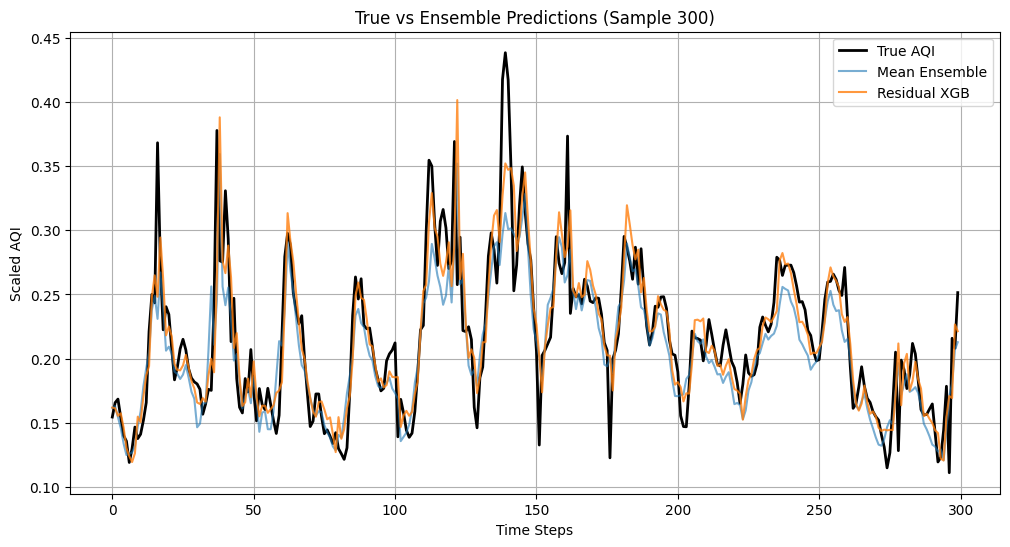

Mean Ensemble R²: 0.818 | XGB Residual-Corrected R²: 0.839


In [12]:
# ------------------- Plot Comparisons -------------------
plt.figure(figsize=(12,6))
plt.plot(y_test[:300], label='True AQI', color='black', linewidth=2)
plt.plot(ensemble_pred[:300], label='Mean Ensemble', alpha=0.6)
plt.plot(ensemble_xgbfix[:300], label='Residual XGB', alpha=0.8)
plt.title('True vs Ensemble Predictions (Sample 300)')
plt.xlabel('Time Steps')
plt.ylabel('Scaled AQI')
plt.legend()
plt.grid(True)
plt.show()

print("Mean Ensemble R²:", round(r2_ens,3), "| XGB Residual-Corrected R²:", round(r2_xgb,3))


Saving trained pipeline for deployment

In [13]:
import joblib

# Save scaler and meta-learner
joblib.dump(scaler, "scaler.pkl")
joblib.dump(meta, "xgb_meta.pkl")

# Save Keras models
cnn_lstm_model.save("cnn_lstm_model.h5")
bilstm_model.save("bilstm_model.h5")
gru_model.save("gru_model.h5")

print("✅ Models and scaler saved successfully.")


✅ Models and scaler saved successfully.


demo 1️⃣ Kerala (moderate humid coastal day)

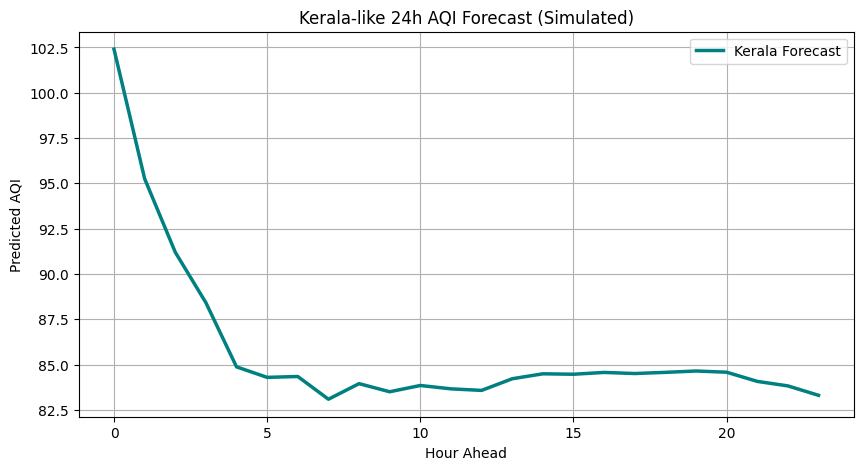

In [21]:
# ------------------- Kerala-like 24h AQI Forecast Demo -------------------
import numpy as np, pandas as pd, matplotlib.pyplot as plt

np.random.seed(42)
hours = np.arange(24)
past_kerala = pd.DataFrame({
    "PM2.5":  np.random.uniform(25, 55, 24),
    "PM10":   np.random.uniform(60,110,24),
    "NO":     np.random.uniform(5, 25, 24),
    "CO":     np.random.uniform(0.3,0.9,24),
    "Ozone":  np.random.uniform(20, 55, 24),
    "temperature_2m": 26 + 2*np.sin(2*np.pi*(hours/24 - 0.25)),
    "relative_humidity_2m": np.random.uniform(70,95,24),
    "precipitation":  np.random.uniform(0.1,0.6,24),
    "rain":           np.random.uniform(0.2,0.8,24),
    "pressure_msl":   np.random.uniform(1005,1015,24),
    "windspeed_10m":  np.random.uniform(2.5,5.5,24),
    "winddirection_10m": np.random.uniform(150,250,24),
    "NO2":            np.random.uniform(20,40,24),
    "Final_AQI":      np.linspace(90,110,24) + np.random.uniform(-5,5,24)
})

future_kerala = pd.concat([past_kerala.iloc[-1:]]*24, ignore_index=True)
future_kerala["PM2.5"] *= 0.85
future_kerala["PM10"]  *= 0.88
future_kerala["NO2"]   *= 0.9
future_kerala["rain"]  += 0.2
future_kerala["precipitation"] += 0.2
future_kerala["Final_AQI"] = np.nan

COLS = list(past_kerala.columns)
def to_scaled(df): return pd.DataFrame(scaler.transform(df[COLS]), columns=COLS)
def inv_aqi(vals):
    z = np.zeros((len(vals), len(COLS))); z[:,COLS.index("Final_AQI")] = vals
    return scaler.inverse_transform(z)[:,COLS.index("Final_AQI")]

def pad_to_36(last24):
    return pd.concat([pd.concat([last24.iloc[[0]]]*12, ignore_index=True), last24], ignore_index=True)

last24, fut24 = to_scaled(past_kerala), to_scaled(future_kerala)
aqi_idx = COLS.index("Final_AQI")
buf36 = pad_to_36(last24)
window24, window36 = last24.copy(), buf36.copy()
preds = []

for t in range(24):
    exog = fut24.iloc[t].copy(); exog["Final_AQI"] = window24.iloc[-1, aqi_idx]
    X24 = np.expand_dims(window24.values,0); X36 = np.expand_dims(window36.values,0)
    p1 = cnn_lstm_model.predict(X24,verbose=0)[0,0]
    p2 = bilstm_model.predict(X24,verbose=0)[0,0]
    p3 = gru_model.predict(X36,verbose=0)[0,0]
    ens = np.mean([p1,p2,p3])
    last_aqi=window24.iloc[-1,aqi_idx]; slope6=window24.iloc[-1,aqi_idx]-window24.iloc[-6,aqi_idx]
    vol24=window24.iloc[-24:,aqi_idx].std(); windlast=window24.iloc[-1,COLS.index("windspeed_10m")]
    ens += meta.predict(np.array([[ens,last_aqi,slope6,vol24,windlast]]))[0]
    preds.append(ens)
    exog["Final_AQI"]=ens
    window24=pd.concat([window24.iloc[1:],exog.to_frame().T],ignore_index=True)
    window36=pd.concat([window36.iloc[1:],exog.to_frame().T],ignore_index=True)

aqi_next24 = inv_aqi(np.array(preds))
plt.figure(figsize=(10,5))
plt.plot(range(24), aqi_next24, color='teal', linewidth=2.5, label="Kerala Forecast")
plt.title("Kerala-like 24h AQI Forecast (Simulated)"); plt.xlabel("Hour Ahead"); plt.ylabel("Predicted AQI")
plt.grid(True); plt.legend(); plt.show()


In [22]:
aqi_kerala = aqi_next24

demo 2️⃣ Agra (dry, dusty, polluted)

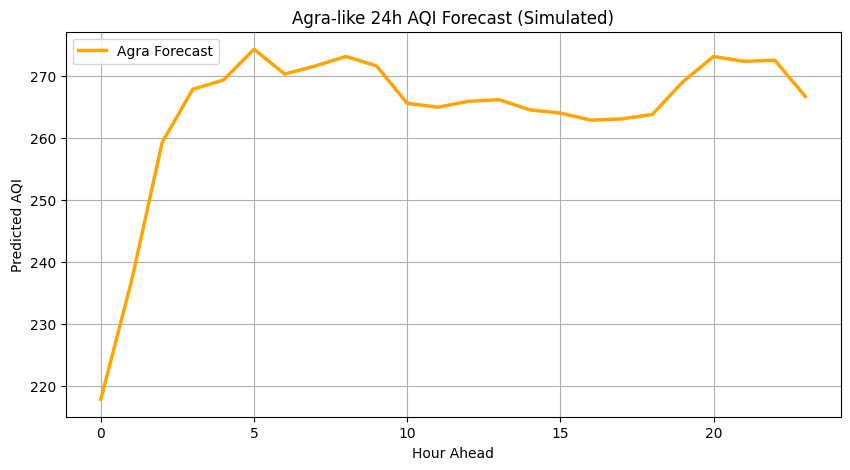

In [23]:
# ------------------- Agra-like 24h AQI Forecast Demo -------------------
import numpy as np, pandas as pd, matplotlib.pyplot as plt

np.random.seed(99)
hours = np.arange(24)
past_agra = pd.DataFrame({
    "PM2.5": np.random.uniform(90,140,24),
    "PM10":  np.random.uniform(160,250,24),
    "NO":    np.random.uniform(10,35,24),
    "CO":    np.random.uniform(0.5,1.2,24),
    "Ozone": np.random.uniform(15,45,24),
    "temperature_2m": 32 + 3*np.sin(2*np.pi*(hours/24 - 0.25)),
    "relative_humidity_2m": np.random.uniform(35,60,24),
    "precipitation": np.random.uniform(0.0,0.2,24),
    "rain": np.random.uniform(0.0,0.1,24),
    "pressure_msl": np.random.uniform(1000,1010,24),
    "windspeed_10m": np.random.uniform(1.0,3.5,24),
    "winddirection_10m": np.random.uniform(50,150,24),
    "NO2": np.random.uniform(45,70,24),
    "Final_AQI": np.linspace(180,210,24)+np.random.uniform(-10,10,24)
})

future_agra = pd.concat([past_agra.iloc[-1:]]*24, ignore_index=True)
future_agra["PM2.5"]*=1.15; future_agra["PM10"]*=1.1; future_agra["NO2"]*=1.1
future_agra["precipitation"]*=0.7; future_agra["rain"]*=0.5; future_agra["Final_AQI"]=np.nan

COLS=list(past_agra.columns)
def to_scaled(df): return pd.DataFrame(scaler.transform(df[COLS]),columns=COLS)
def inv_aqi(vals):
    z=np.zeros((len(vals),len(COLS))); z[:,COLS.index("Final_AQI")]=vals
    return scaler.inverse_transform(z)[:,COLS.index("Final_AQI")]

def pad_to_36(last24):
    return pd.concat([pd.concat([last24.iloc[[0]]]*12, ignore_index=True), last24], ignore_index=True)

last24,fut24=to_scaled(past_agra),to_scaled(future_agra)
aqi_idx=COLS.index("Final_AQI"); buf36=pad_to_36(last24)
window24,window36=last24.copy(),buf36.copy(); preds=[]
for t in range(24):
    exog=fut24.iloc[t].copy(); exog["Final_AQI"]=window24.iloc[-1,aqi_idx]
    X24=np.expand_dims(window24.values,0); X36=np.expand_dims(window36.values,0)
    p1=cnn_lstm_model.predict(X24,verbose=0)[0,0]
    p2=bilstm_model.predict(X24,verbose=0)[0,0]
    p3=gru_model.predict(X36,verbose=0)[0,0]
    ens=np.mean([p1,p2,p3])
    last_aqi=window24.iloc[-1,aqi_idx]; slope6=window24.iloc[-1,aqi_idx]-window24.iloc[-6,aqi_idx]
    vol24=window24.iloc[-24:,aqi_idx].std(); windlast=window24.iloc[-1,COLS.index("windspeed_10m")]
    ens+=meta.predict(np.array([[ens,last_aqi,slope6,vol24,windlast]]))[0]
    preds.append(ens)
    exog["Final_AQI"]=ens
    window24=pd.concat([window24.iloc[1:],exog.to_frame().T],ignore_index=True)
    window36=pd.concat([window36.iloc[1:],exog.to_frame().T],ignore_index=True)

aqi_next24=inv_aqi(np.array(preds))
plt.figure(figsize=(10,5))
plt.plot(range(24),aqi_next24,color='orange',linewidth=2.5,label="Agra Forecast")
plt.title("Agra-like 24h AQI Forecast (Simulated)"); plt.xlabel("Hour Ahead"); plt.ylabel("Predicted AQI")
plt.grid(True); plt.legend(); plt.show()


In [24]:
aqi_agra = aqi_next24

demo 3️⃣ Heavy Rain (monsoon-like washout test)

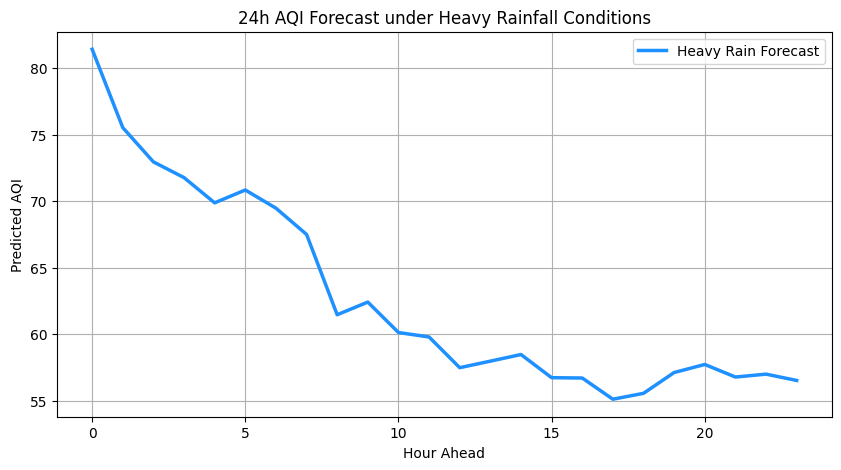

Mean AQI: 62.76 | Min: 55.1 | Max: 81.43


In [25]:
# ------------------- Heavy Rainfall 24h AQI Forecast Demo -------------------
import numpy as np, pandas as pd, matplotlib.pyplot as plt

np.random.seed(2025)
hours=np.arange(24)
past_rain=pd.DataFrame({
    "PM2.5": np.random.uniform(20,45,24),
    "PM10": np.random.uniform(40,90,24),
    "NO": np.random.uniform(3,15,24),
    "CO": np.random.uniform(0.2,0.8,24),
    "Ozone": np.random.uniform(10,35,24),
    "temperature_2m": 24+1.5*np.sin(2*np.pi*(hours/24-0.25)),
    "relative_humidity_2m": np.random.uniform(90,100,24),
    "precipitation": np.random.uniform(3.0,10.0,24),
    "rain": np.ones(24),
    "pressure_msl": np.random.uniform(1000,1010,24),
    "windspeed_10m": np.random.uniform(4.5,7.0,24),
    "winddirection_10m": np.random.uniform(180,270,24),
    "NO2": np.random.uniform(15,30,24),
    "Final_AQI": np.linspace(80,95,24)+np.random.uniform(-4,4,24)
})

future_rain=pd.concat([past_rain.iloc[-1:]]*24,ignore_index=True)
future_rain["PM2.5"]*=0.8; future_rain["PM10"]*=0.85; future_rain["NO2"]*=0.9
future_rain["precipitation"]=np.random.uniform(4.0,12.0,24)
future_rain["rain"]=1.0; future_rain["relative_humidity_2m"]=np.random.uniform(95,100,24)
future_rain["temperature_2m"]=23+1*np.sin(2*np.pi*(hours/24-0.25))
future_rain["Final_AQI"]=np.nan

COLS=list(past_rain.columns)
def to_scaled(df): return pd.DataFrame(scaler.transform(df[COLS]),columns=COLS)
def inv_aqi(vals):
    z=np.zeros((len(vals),len(COLS))); z[:,COLS.index("Final_AQI")]=vals
    return scaler.inverse_transform(z)[:,COLS.index("Final_AQI")]
def pad_to_36(last24):
    return pd.concat([pd.concat([last24.iloc[[0]]]*12,ignore_index=True),last24],ignore_index=True)

last24,fut24=to_scaled(past_rain),to_scaled(future_rain)
aqi_idx=COLS.index("Final_AQI"); buf36=pad_to_36(last24)
window24,window36=last24.copy(),buf36.copy(); preds=[]
for t in range(24):
    exog=fut24.iloc[t].copy(); exog["Final_AQI"]=window24.iloc[-1,aqi_idx]
    X24=np.expand_dims(window24.values,0); X36=np.expand_dims(window36.values,0)
    p1=cnn_lstm_model.predict(X24,verbose=0)[0,0]
    p2=bilstm_model.predict(X24,verbose=0)[0,0]
    p3=gru_model.predict(X36,verbose=0)[0,0]
    ens=np.mean([p1,p2,p3])
    last_aqi=window24.iloc[-1,aqi_idx]; slope6=window24.iloc[-1,aqi_idx]-window24.iloc[-6,aqi_idx]
    vol24=window24.iloc[-24:,aqi_idx].std(); windlast=window24.iloc[-1,COLS.index("windspeed_10m")]
    ens+=meta.predict(np.array([[ens,last_aqi,slope6,vol24,windlast]]))[0]
    preds.append(ens)
    exog["Final_AQI"]=ens
    window24=pd.concat([window24.iloc[1:],exog.to_frame().T],ignore_index=True)
    window36=pd.concat([window36.iloc[1:],exog.to_frame().T],ignore_index=True)

aqi_next24=inv_aqi(np.array(preds))
plt.figure(figsize=(10,5))
plt.plot(range(24),aqi_next24,color='dodgerblue',linewidth=2.5,label="Heavy Rain Forecast")
plt.title("24h AQI Forecast under Heavy Rainfall Conditions")
plt.xlabel("Hour Ahead"); plt.ylabel("Predicted AQI"); plt.grid(True); plt.legend(); plt.show()

print("Mean AQI:",round(np.mean(aqi_next24),2),"| Min:",round(np.min(aqi_next24),2),"| Max:",round(np.max(aqi_next24),2))


In [26]:
aqi_rain = aqi_next24

side by side checck on how weather affects aqi

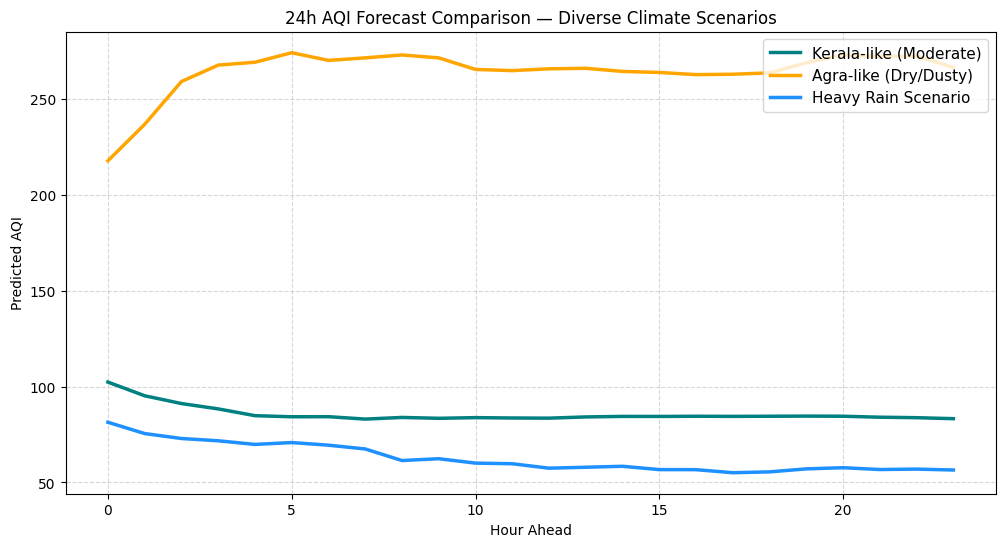

Average AQIs — Kerala: 85.8 | Agra: 264.4 | Heavy Rain: 62.8


In [27]:
# ------------------- Comparative AQI Forecast Visualization -------------------
import matplotlib.pyplot as plt
import numpy as np

# Check all three simulations exist
try:
    kerala_aqi = aqi_next24.copy()  # from last cell (heavy rain)
except NameError:
    print("⚠️ Please run the three scenario cells first (Kerala, Agra, Heavy Rain).")
else:
    # We assume your three AQI arrays are named differently
    # Rename them explicitly below after running each cell:
    # Kerala cell -> aqi_kerala
    # Agra cell -> aqi_agra
    # Heavy rain cell -> aqi_rain

    try:
        aqi_kerala
        aqi_agra
        aqi_rain
    except NameError:
        print("⚠️ Make sure you renamed AQI arrays after each run as follows:\n"
              "  aqi_kerala = aqi_next24 (from Kerala cell)\n"
              "  aqi_agra = aqi_next24 (from Agra cell)\n"
              "  aqi_rain = aqi_next24 (from Heavy Rain cell)")
    else:
        hours = np.arange(24)
        plt.figure(figsize=(12,6))
        plt.plot(hours, aqi_kerala, color='teal', linewidth=2.5, label='Kerala-like (Moderate)')
        plt.plot(hours, aqi_agra, color='orange', linewidth=2.5, label='Agra-like (Dry/Dusty)')
        plt.plot(hours, aqi_rain, color='dodgerblue', linewidth=2.5, label='Heavy Rain Scenario')

        plt.title("24h AQI Forecast Comparison — Diverse Climate Scenarios")
        plt.xlabel("Hour Ahead")
        plt.ylabel("Predicted AQI")
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(fontsize=11, loc='upper right')
        plt.show()

        # Optional summary stats
        print("Average AQIs — Kerala:", round(np.mean(aqi_kerala),1),
              "| Agra:", round(np.mean(aqi_agra),1),
              "| Heavy Rain:", round(np.mean(aqi_rain),1))
